# <FONT COLOR="Red">Épisode 3 : CART, Agrégation de modèles</font>

Dc ici je reprends la structure de la pt 3 3 du TP ozone, mais en l'appliquant a notre jeu de données `healthcare_synthetic_data.csv`.

Objectif: prédire `Heart_Disease_Risk` à partir des variables avec:
- un arbre binaire de décision (CART),
- une forêt aléatoire.

In [15]:
#librairies ect tu connais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
# Chargement des données
healthcare = pd.read_csv('/home/gugubre/Cours/ML_Projet/ML-project/divers/healthcare_synthetic_data.csv')
healthcare.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [16]:
# Préparation de la matrice de travail, des splits ect tu connais
# Patient_ID est un identifiant, il n'est donc pas utilisé comme variable explicative.=> on vire
dfC = healthcare.drop(columns=['Patient_ID', 'Heart_Disease_Risk'])
Yb = healthcare['Heart_Disease_Risk']

X_train, X_test, Yb_train, Yb_test = train_test_split(
    dfC,
    Yb,
    test_size=0.25,
    random_state=42,
    stratify=Yb,
)

Xr_train, Xr_test = X_train, X_test

print('Dimensions apprentissage :', Xr_train.shape)
print('Dimensions test :', Xr_test.shape)
print('Taux de classe positive (train) :', round(Yb_train.mean(), 3))
print('Taux de classe positive (test) :', round(Yb_test.mean(), 3))

Dimensions apprentissage : (11250, 17)
Dimensions test : (3750, 17)
Taux de classe positive (train) : 0.436
Taux de classe positive (test) : 0.436


### [Arbre binaire de décision (CART)](http://wikistat.fr/pdf/st-m-app-cart.pdf)

. Comme dans le TP ozone, on commence par ajuster la profondeur maximale de l'arbre par validation croisée.

In [4]:
# Optimisation de la profondeur de l'arbre
param = [{"max_depth": list(range(2, 10))}]
tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param, cv=10, n_jobs=-1)
treeOpt = tree.fit(Xr_train, Yb_train)

print(
    "Meilleur score = %f, Meilleur paramètre = %s"
    % (1.0 - treeOpt.best_score_, treeOpt.best_params_)
)

Meilleur score = 0.287822, Meilleur paramètre = {'max_depth': 6}


In [5]:
# Estimation de l'erreur de prévision
1 - treeOpt.score(Xr_test, Yb_test)

0.29733333333333334

In [17]:
# Prévision de l'échantillon test
#  et aussi Matrice de confusion

y_chap = treeOpt.predict(Xr_test)
table = pd.crosstab(
    pd.Series(y_chap, name='Prediction'),
    pd.Series(Yb_test, name='Observation')
)
print(table)

Observation    0    1
Prediction           
0            345  261
1            185  146


`plot_tree()` on l'utilise pour afficher l'arbre selon le tp

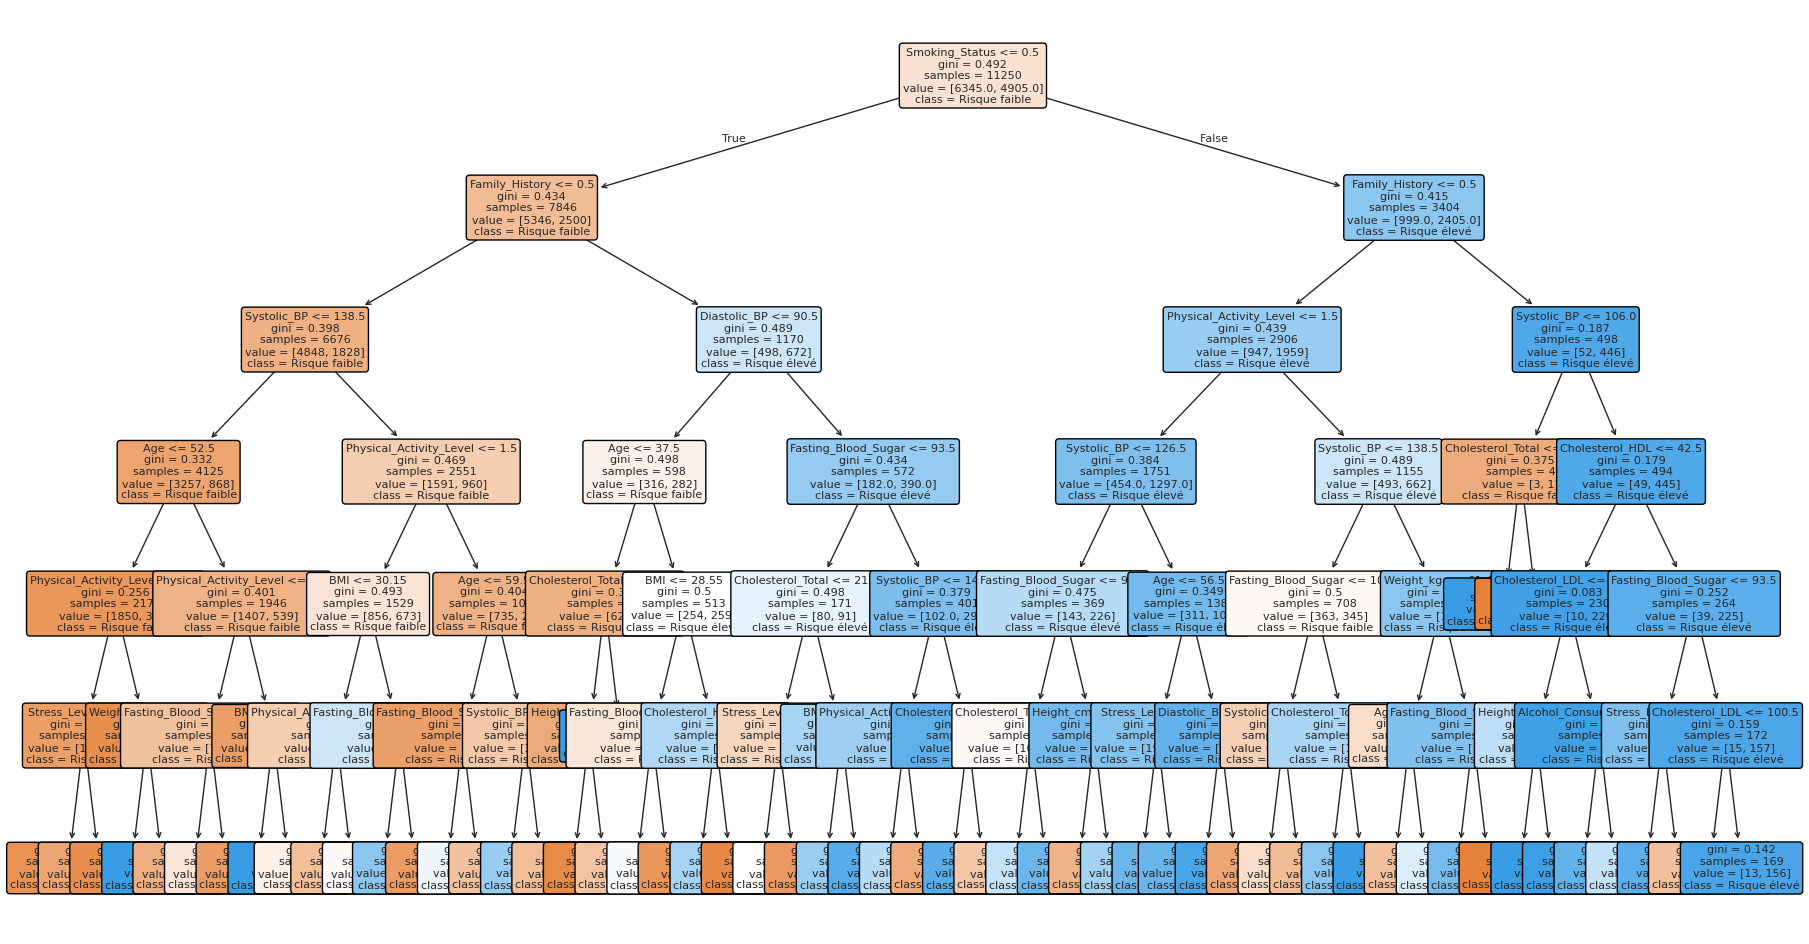

In [7]:
treeG = DecisionTreeClassifier(max_depth=treeOpt.best_params_['max_depth'], random_state=42)
treeG.fit(Xr_train, Yb_train)

plt.figure(figsize=(22, 12))
plot_tree(
    treeG,
    feature_names=dfC.columns.tolist(),
    class_names=['Risque faible', 'Risque élevé'],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.show()

## Forêts aléatoires ou random forest pour dondedz



On passe ensuite à une agrégation de modèles par forêts aléatoires. Comme dans le TP ozone, on commence par un modèle avec paramètres fixés puis on affine le paramètre `max_features` par cross-val

In [18]:
# Définition des paramètres du Random Forest
forest = RandomForestClassifier(
    n_estimators=500,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    max_leaf_nodes=None,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)

# Apprentissage
rfFit = forest.fit(Xr_train, Yb_train)

print('Erreur out-of-bag :', 1 - rfFit.oob_score_)

Erreur out-of-bag : 0.26959999999999995


on regarde qui est le mieux entre le spoli ou l'erreru OOB

In [9]:
# Erreur de prévision sur le test
1 - rfFit.score(Xr_test, Yb_test)

0.2770666666666667


on optimise le nb de var tirées randomement quand on construit chaque noeud par Cross-val 

In [10]:
param = [{"max_features": list(range(2, 10, 1))}]
rf = GridSearchCV(RandomForestClassifier(n_estimators=100, random_state=42), param, cv=5, n_jobs=-1)
rfOpt = rf.fit(Xr_train, Yb_train)

print(
    "Meilleur score = %f, Meilleur paramètre = %s"
    % (1.0 - rfOpt.best_score_, rfOpt.best_params_)
)

Meilleur score = 0.268267, Meilleur paramètre = {'max_features': 3}



-> exécutions, rendues partiellement aléatoires par la cross val et l'algorithme lui-mêmeon obtient noramelement des valeurs "optimales" différentes sans dégrader  la qualité de prévision de l'arbre.

In [11]:
# Erreur de prévision sur le test
1 - rfOpt.score(Xr_test, Yb_test)

0.28613333333333335

In [12]:
# Prévision
# Matrice de confusion

y_chap = rfFit.predict(Xr_test)
table = pd.crosstab(
    pd.Series(y_chap, name='Prediction'),
    pd.Series(Yb_test, name='Observation')
)
print(table)

Observation    0    1
Prediction           
0            331  255
1            199  152




Comme dans le TP ozone, on calcule ensuite un indicateur d'importance des variables pour guider l'interprétation.

In [13]:
rf = RandomForestClassifier(n_estimators=100, max_features=2, random_state=42, n_jobs=-1)
rfFit = rf.fit(Xr_train, Yb_train)

# Importance décroissante des variables
importances = rfFit.feature_importances_
indices = np.argsort(importances)[::-1]

for f in range(Xr_train.shape[1]):
    print(dfC.columns[indices[f]], importances[indices[f]])

Smoking_Status 0.10671713179607924
Fasting_Blood_Sugar 0.07630434606600096
Systolic_BP 0.07540461678198665
Age 0.07447427184399702
Weight_kg 0.07439423594865642
BMI 0.07236171575015053
Cholesterol_Total 0.07034239868617449
Height_cm 0.0701630709813972
Cholesterol_LDL 0.06921618086542841
Diastolic_BP 0.0652263774821061
Cholesterol_HDL 0.05772859179590152
Stress_Level 0.050392309021329074
Physical_Activity_Level 0.038239970968483875
Sleep_Hours 0.03546797264349131
Family_History 0.03268928224084735
Alcohol_Consumption 0.01994887279655278
Gender 0.01092865433141721


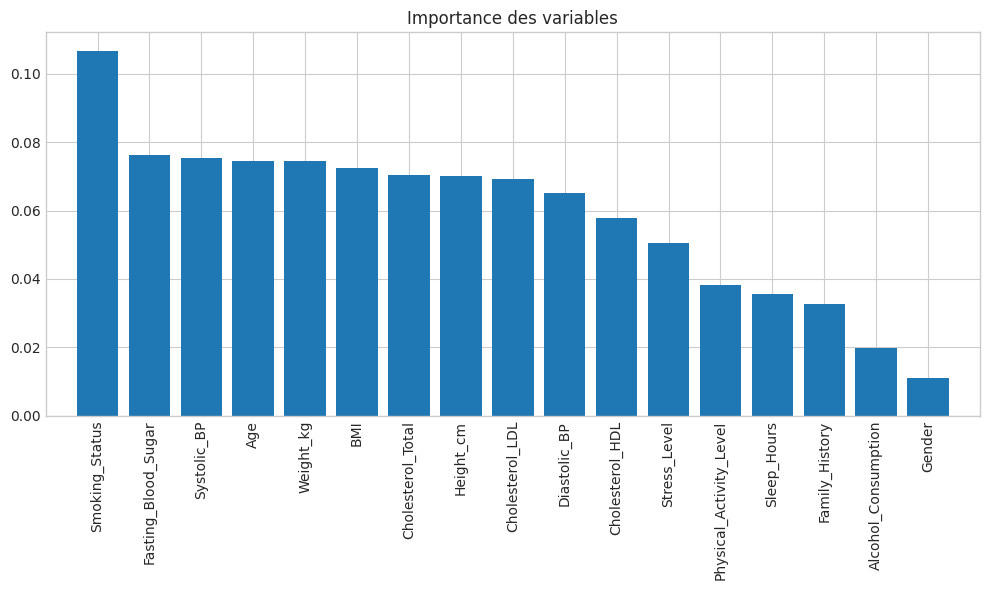

In [14]:
# Graphe des importances
plt.figure(figsize=(10, 6))
plt.title('Importance des variables')
plt.bar(range(Xr_train.shape[1]), importances[indices])
plt.xticks(range(Xr_train.shape[1]), dfC.columns[indices], rotation=90)
plt.xlim([-1, Xr_train.shape[1]])
plt.tight_layout()
plt.show()

Le smoking et le fasting sont les deux variables les plus importantes pour la prédiction du risque de maladie cardiaque dans ce modèle.